<a href="https://colab.research.google.com/github/sneha200421/sentiment_analysis/blob/main/trained_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import re
from google.colab import drive
from torch.utils.data import DataLoader, Dataset
from transformers import DistilBertModel, DistilBertTokenizer
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from datasets import load_dataset
from tqdm.auto import tqdm

NUM_EPOCHS = 30
MAX_LEN = 256
BATCH_SIZE = 16
LEARNING_RATE = 1e-5

# 1. SETUP
drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

print(f"Using device: {device}") # Verification check for GPU

# 2. DATA LOADING & CLEANING
df_kag = pd.read_csv('/content/drive/MyDrive/CombinedData.csv')
df_kag.dropna(subset=['status', 'statement'], inplace=True)

dataset = load_dataset("google-research-datasets/go_emotions", "simplified", split='train')
df_go = pd.DataFrame(dataset)

negative_emotions = [0, 1, 2, 3, 5, 10, 11, 14, 16, 19, 24, 26]
def map_go_sentiment(labels_list):
    if any(i in labels_list for i in negative_emotions):
        return 0
    return 1

df_go['sentiment_labels'] = df_go['labels'].apply(map_go_sentiment)
df_go = df_go.rename(columns={'text': 'statement'})

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-zA-Z!?\s]', '', text)
    return text.strip()

df_kag['text'] = df_kag['statement'].apply(clean_text)
sentiment_map = {'Normal': 1, 'Depression': 0, 'Suicidal': 0, 'Anxiety': 0, 'Stress': 0, 'Bi-Polar': 0, 'Personality Disorder': 0}

df_kag['sentiment_labels'] = df_kag['status'].map(sentiment_map)
df_kag.dropna(subset=['sentiment_labels'], inplace=True)
df_kag['sentiment_labels'] = df_kag['sentiment_labels'].astype(int)

df_kag['mh_labels'] = df_kag['status'].astype('category').cat.codes
class_names = df_kag['status'].astype('category').cat.categories

df_go['text'] = df_go['statement'].apply(clean_text)
df_go['mh_labels'] = -1

combined_df = pd.concat([
    df_kag[['text', 'sentiment_labels', 'mh_labels']],
    df_go[['text', 'sentiment_labels', 'mh_labels']].sample(15000)
]).sample(frac=1).reset_index(drop=True)

# 3. OPTIMIZED DATASET & MODEL
class MultiTaskDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.data = dataframe
        # Tokenize everything ALL AT ONCE for speed
        self.encodings = tokenizer(
            dataframe['text'].tolist(),
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        return {
            'input_ids': self.encodings['input_ids'][index],
            'attention_mask': self.encodings['attention_mask'][index],
            'sentiment_targets': torch.tensor(int(row['sentiment_labels']), dtype=torch.long),
            'mh_targets': torch.tensor(int(row['mh_labels']), dtype=torch.long)
        }

class MultiTaskModel(nn.Module):
    def __init__(self, num_mh, num_sent):
        super(MultiTaskModel, self).__init__()
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.dropout = nn.Dropout(0.2)
        self.mh_head = nn.Linear(768, num_mh)
        self.sentiment_head = nn.Linear(768, num_sent)

    def forward(self, ids, mask):
        output = self.distilbert(ids, attention_mask=mask)
        pooled = output[0][:, 0]
        pooled = self.dropout(pooled)
        return self.mh_head(pooled), self.sentiment_head(pooled)

# 4. PREPARE FAST TRAINING
train_df, val_df = train_test_split(combined_df, test_size=0.15, random_state=42)

# num_workers and pin_memory speed up GPU data transfer
train_loader = DataLoader(
    MultiTaskDataset(train_df, tokenizer, MAX_LEN),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    MultiTaskDataset(val_df, tokenizer, MAX_LEN),
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True
)

model = MultiTaskModel(len(class_names), 2).to(device)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
criterion_mh = nn.CrossEntropyLoss(ignore_index=-1)
criterion_sent = nn.CrossEntropyLoss()

# Scaler for Automatic Mixed Precision (AMP)
scaler = torch.amp.GradScaler('cuda')

# 5. EXECUTE (TRAINING + VALIDATION)
print(f"Starting Training for {NUM_EPOCHS} Epochs...")
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0
    loop = tqdm(train_loader, leave=False, desc=f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train")

    for batch in loop:
        ids, mask = batch['input_ids'].to(device), batch['attention_mask'].to(device)
        mh_t, s_t = batch['mh_targets'].to(device), batch['sentiment_targets'].to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            mh_l, s_l = model(ids, mask)
            loss = criterion_mh(mh_l, mh_t) + criterion_sent(s_l, s_t)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        val_loop = tqdm(val_loader, leave=False, desc=f"Epoch [{epoch+1}/{NUM_EPOCHS}] Val")
        for batch in val_loop:
            ids, mask = batch['input_ids'].to(device), batch['attention_mask'].to(device)
            mh_t, s_t = batch['mh_targets'].to(device), batch['sentiment_targets'].to(device)

            with torch.amp.autocast('cuda'):
                mh_l, s_l = model(ids, mask)
                loss = criterion_mh(mh_l, mh_t) + criterion_sent(s_l, s_t)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # --- SAVE BEST MODEL ---
    if avg_val_loss < best_val_loss:
        print(f"--> Validation loss improved from {best_val_loss:.4f} to {avg_val_loss:.4f}. Saving model!")
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'multi_task_best_model.pth')

print("Training Complete! Best model saved as 'multi_task_best_model.pth'")

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch [29/30] Val:   0%|          | 0/599 [00:00<?, ?it/s]

Epoch 29/30 | Train Loss: 0.0191 | Val Loss: 1.5385


Epoch [30/30] Train:   0%|          | 0/3391 [00:00<?, ?it/s]

Epoch [30/30] Val:   0%|          | 0/599 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss: 0.0181 | Val Loss: 1.6224
Training Complete! Best model saved as 'multi_task_best_model.pth'


In [ ]:
model.eval()
all_mh_preds, all_mh_labels = [], []
all_sent_preds, all_sent_labels = [], []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating"):
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        mh_t = batch['mh_targets'].to(device)
        s_t = batch['sentiment_targets'].to(device)

        mh_logits, sent_logits = model(ids, mask)

        # We only evaluate MH labels that aren't -1 (ignoring GoEmotions dummy labels)
        mask_mh = mh_t != -1
        if mask_mh.any():
            all_mh_preds.extend(torch.argmax(mh_logits[mask_mh], dim=1).cpu().numpy())
            all_mh_labels.extend(mh_t[mask_mh].cpu().numpy())

        all_sent_preds.extend(torch.argmax(sent_logits, dim=1).cpu().numpy())
        all_sent_labels.extend(s_t.cpu().numpy())

Evaluating:   0%|          | 0/599 [00:00<?, ?it/s]

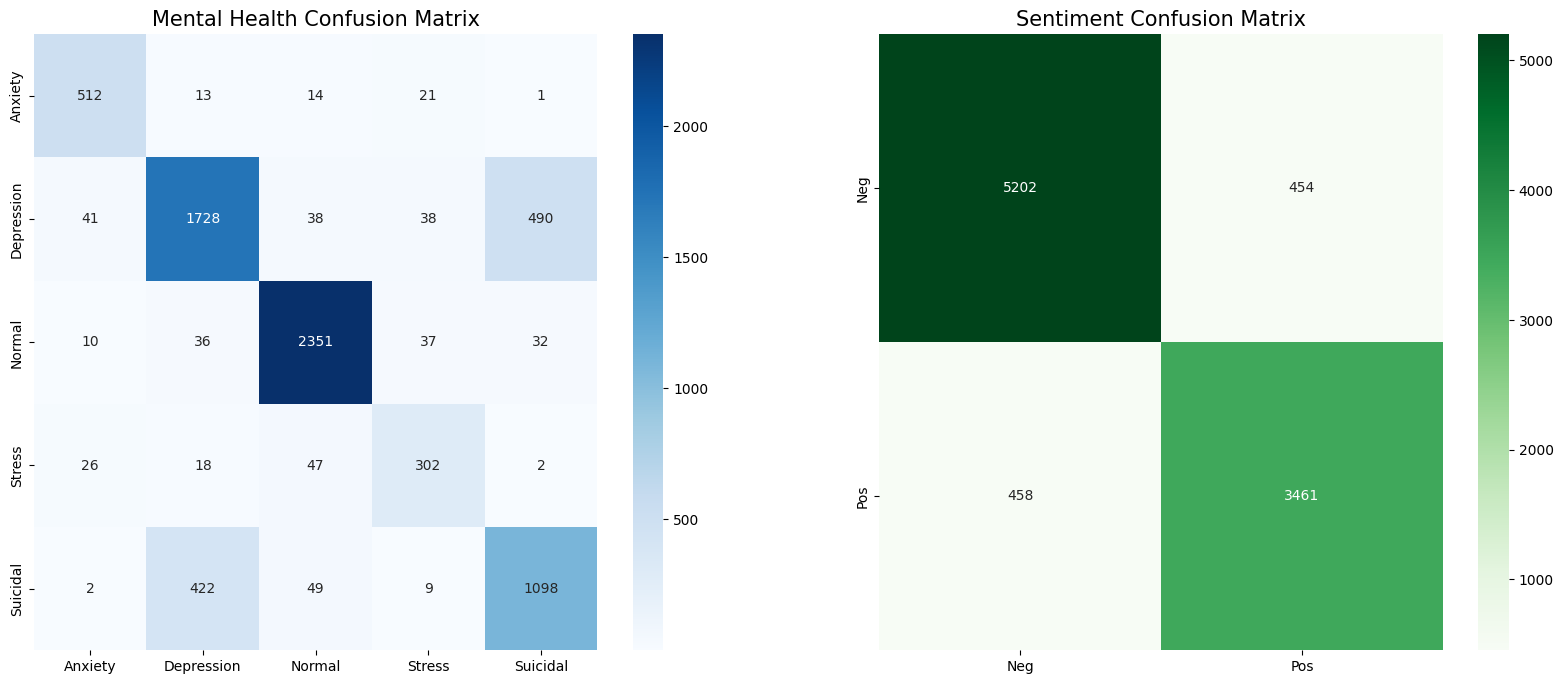

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# MH Matrix
cm_mh = confusion_matrix(all_mh_labels, all_mh_preds)
sns.heatmap(cm_mh, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax[0])
ax[0].set_title('Mental Health Confusion Matrix', fontsize=15)

# Sentiment Matrix
cm_sent = confusion_matrix(all_sent_labels, all_sent_preds)
sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Greens', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'], ax=ax[1])
ax[1].set_title('Sentiment Confusion Matrix', fontsize=15)

plt.show()

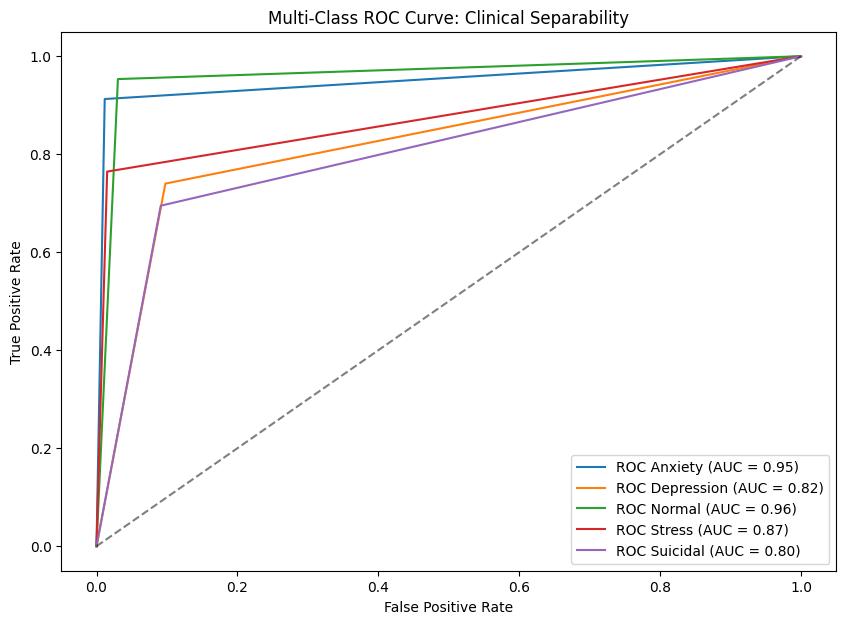

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize for multi-class ROC
Y_test = label_binarize(all_mh_labels, classes=range(len(class_names)))
Y_score = label_binarize(all_mh_preds, classes=range(len(class_names)))

plt.figure(figsize=(10, 7))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(Y_test[:, i], Y_score[:, i])
    plt.plot(fpr, tpr, label=f'ROC {class_names[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Multi-Class ROC Curve: Clinical Separability')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()